In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
os.environ["KAGGLEHUB_CACHE"] = "/Volumes/SecureSSD/Projects/LearningML/kaggle"

In [47]:
path = kagglehub.dataset_download("ishanshrivastava28/superstore-sales")


In [48]:
df = pd.read_csv(path+'/'+'Superstore.csv', encoding='latin1')

In [49]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [50]:
df[df["Profit"] < 0].head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
14,15,US-2012-118983,22-11-2012,26-11-2012,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580
15,16,US-2012-118983,22-11-2012,26-11-2012,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160
23,24,US-2014-156909,17-07-2014,19-07-2014,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
27,28,US-2012-150630,17-09-2012,21-09-2012,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522


In [51]:
df.where(df['Profit'] > 0).dropna().head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1.0,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2.0,0.0,41.9136
1,2.0,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3.0,0.0,219.5820
2,3.0,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2.0,0.0,6.8714
4,5.0,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2.0,0.2,2.5164
5,6.0,CA-2011-115812,09-06-2011,14-06-2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7.0,0.0,14.1694


In [52]:
df.pivot_table(values='Discount', index='Ship Mode', aggfunc='mean')

,Discount
Ship Mode,
First Class,0.164610
Same Day,0.152394
Second Class,0.138895
Standard Class,0.160023


In [53]:
df['Category'].value_counts()
df.groupby(df['Category']).count()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Category,,,,,,,,,,,,,,,,,,,,
Furniture,2121,2121,2121,2121,2121,2121,2121,2121,2121,2121,2121,2121,2121,2121,2121,2121,2121,2121,2121,2121
Office Supplies,6026,6026,6026,6026,6026,6026,6026,6026,6026,6026,6026,6026,6026,6026,6026,6026,6026,6026,6026,6026
Technology,1847,1847,1847,1847,1847,1847,1847,1847,1847,1847,1847,1847,1847,1847,1847,1847,1847,1847,1847,1847


In [54]:
df[df.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [55]:
maxprof = df['Profit'].max()
last_bin = max(100000,maxprof+1)
profit = pd.cut(df['Profit'], bins=[-10000,0,1000,5000,10000,last_bin], duplicates='drop')
profit.value_counts()

Profit
(0, 1000]          8016
(-10000, 0]        1936
(1000, 5000]         39
(5000, 10000]         3
(10000, 100000]       0
Name: count, dtype: int64

In [56]:
df[df['State'].isin(['California', 'Texas'])]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
5,6,CA-2011-115812,09-06-2011,14-06-2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
6,7,CA-2011-115812,09-06-2011,14-06-2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656
7,8,CA-2011-115812,09-06-2011,14-06-2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6,0.2,90.7152
8,9,CA-2011-115812,09-06-2011,14-06-2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,0.2,5.7825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9986,9987,CA-2013-125794,30-09-2013,04-10-2013,Standard Class,ML-17410,Maris LaWare,Consumer,United States,Los Angeles,...,90008,West,TEC-AC-10003399,Technology,Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.240,1,0.0,15.2208
9990,9991,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200


In [57]:
df['Profit_Tag'] = df['Profit'].apply(lambda x:'Profit' if x >= 0 else 'Loss')
df[['Product Name','Profit','Profit_Tag']]

,Product Name,Profit,Profit_Tag
0,Bush Somerset Collection Bookcase,41.9136,Profit
1,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",219.5820,Profit
2,Self-Adhesive Address Labels for Typewriters b...,6.8714,Profit
3,Bretford CR4500 Series Slim Rectangular Table,-383.0310,Loss
4,Eldon Fold 'N Roll Cart System,2.5164,Profit
...,...,...,...
9989,Ultra Door Pull Handle,4.1028,Profit
9990,Tenex B1-RE Series Chair Mats for Low Pile Car...,15.6332,Profit
9991,Aastra 57i VoIP phone,19.3932,Profit
9992,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",13.3200,Profit


In [44]:
# Class  2

In [45]:
# 1) Find 25, 50, 75, 90, percentile on sales and profit
# 2) Split sales into four quartiles



In [62]:
sales_np = np.array(df['Sales'])
profit_np = np.array(df['Profit'])

In [64]:
np.percentile(sales_np, [25, 50, 75, 90])

array([ 17.28 ,  54.49 , 209.94 , 572.706])

In [65]:
np.percentile(profit_np, [25, 50, 75, 90])

array([ 1.72875,  8.6665 , 29.364  , 89.28162])

In [85]:
quart = np.quantile(sales_np, [0.25, 0.50, 0.75, 1.0])
quart

array([1.728000e+01, 5.449000e+01, 2.099400e+02, 2.263848e+04])

In [74]:
np.max(sales_np)


np.float64(22638.48)

In [75]:
sales_np[sales_np < 17.28]

array([14.62 ,  7.28 , 15.552, ..., 13.86 , 13.376, 16.52 ], shape=(2498,))

In [77]:
sales_np.size/4

2498.5

In [78]:
np.histogram(sales_np, bins = 4)

(array([9979,   12,    1,    2]),
 array([4.4400000e-01, 5.6599530e+03, 1.1319462e+04, 1.6978971e+04,
        2.2638480e+04]))

In [81]:
pd.qcut(df['Sales'], 4, retbins = True)

(0       (209.94, 22638.48]
 1       (209.94, 22638.48]
 2           (0.443, 17.28]
 3       (209.94, 22638.48]
 4           (17.28, 54.49]
                ...        
 9989        (17.28, 54.49]
 9990       (54.49, 209.94]
 9991    (209.94, 22638.48]
 9992        (17.28, 54.49]
 9993    (209.94, 22638.48]
 Name: Sales, Length: 9994, dtype: category
 Categories (4, interval[float64, right]): [(0.443, 17.28] < (17.28, 54.49] < (54.49, 209.94] < (209.94, 22638.48]],
 array([4.440000e-01, 1.728000e+01, 5.449000e+01, 2.099400e+02,
        2.263848e+04]))

In [90]:
abs(quart[0] - quart[2])

np.float64(192.66)

In [126]:
quart_a = np.digitize(sales_np, quart)
df['quart'] = np.transpose(quart_a)
df[df['Category'] == 'Technology'].groupby('quart')['Category'].value_counts()
# cuut = pd.cut(df['Sales'], quart)
pd.cut(df['Sales'], bins=4)

0       (-22.194, 5659.953]
1       (-22.194, 5659.953]
2       (-22.194, 5659.953]
3       (-22.194, 5659.953]
4       (-22.194, 5659.953]
               ...         
9989    (-22.194, 5659.953]
9990    (-22.194, 5659.953]
9991    (-22.194, 5659.953]
9992    (-22.194, 5659.953]
9993    (-22.194, 5659.953]
Name: Sales, Length: 9994, dtype: category
Categories (4, interval[float64, right]): [(-22.194, 5659.953] < (5659.953, 11319.462] < (11319.462, 16978.971] < (16978.971, 22638.48]]

In [127]:
print(df[df['Category'] == 'Technology'].groupby('quart')['Sales'].max()
     )
print("----")
print(df[df['Category'] == 'Technology'].groupby('quart')['Sales'].min()
     )

quart
0       16.990
1       54.384
2      209.930
3    17499.950
4    22638.480
Name: Sales, dtype: float64
----
quart
0        0.990
1       17.520
2       55.176
3      209.940
4    22638.480
Name: Sales, dtype: float64


In [169]:
# Which customer segment contributes most to the top 10 percent of profit
df['Decentile'] = pd.qcut(df['Profit'], 10, labels = False)
df[df['Decentile'] == 9].groupby('Segment')['Profit'].sum().sort_values(ascending = False).reset_index()

,Segment,Profit
0,Consumer,150284.2705
1,Corporate,97501.9766
2,Home Office,62699.4513


In [173]:
df[df['Segment'] == 'Consumer'].groupby('Decentile')['Customer ID'].count().reset_index(drop = True)

0    538
1    535
2    526
3    522
4    503
5    521
6    528
7    506
8    529
9    483
Name: Customer ID, dtype: int64

In [183]:
df.groupby('Region')['Sales'].var().sort_values(ascending = False).reset_index().head(1)

,Region,Sales
0,South,600309.263888


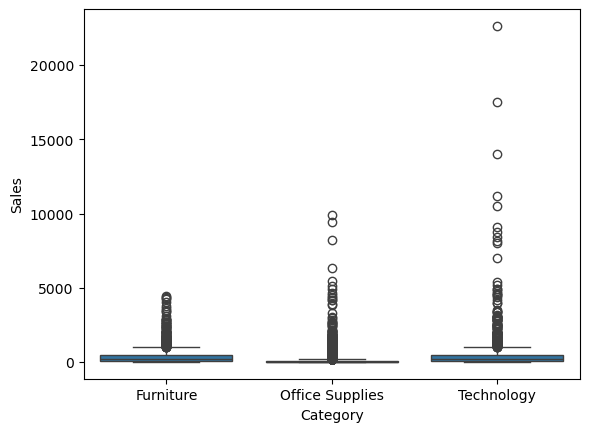

In [189]:
sns.boxplot(x = 'Category', y = 'Sales', data = df)
plt.show()

In [196]:
df[(df['Sales'] < quart[0] - 1.5*abs(quart[0] - quart[2])) | (df['Sales'] > quart[2] + 1.5*abs(quart[0] - quart[2]))].groupby('Category')['Sales'].count().reset_index()

,Category,Sales
0,Furniture,467
1,Office Supplies,300
2,Technology,400


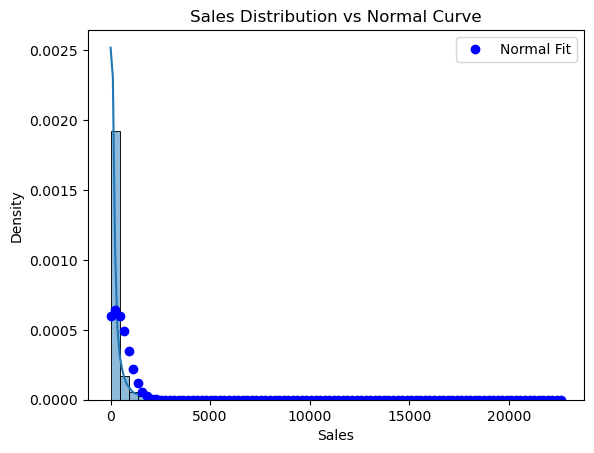

In [203]:
from scipy.stats import norm

mu_sales, sigma_sales = df['Sales'].mean(), df['Sales'].std()
sns.histplot(df['Sales'], kde=True, stat='density', bins=50)
x = np.linspace(df['Sales'].min(), df['Sales'].max(), 100)
plt.plot(x, norm.pdf(x, mu_sales, sigma_sales), "bo", lw=2, label="Normal Fit")
plt.legend()
plt.title("Sales Distribution vs Normal Curve")
plt.savefig("sales_distribution.png")